In [1]:
import os
import cv2
import torch
import numpy as np
import supervision as sv
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator


DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

sam = sam_model_registry["vit_h"](checkpoint="../weights/sam_vit_h_4b8939.pth")
sam.to(device=DEVICE)
mask_generator = SamAutomaticMaskGenerator(sam)


depth_estimator = pipeline(task="depth-estimation", 
                           model="LiheYoung/depth-anything-small-hf", 
                           device=0 if torch.cuda.is_available() else -1)


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

In [9]:
IMAGE_PATH = "../data/raw_images/img_11.jpg" 


image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

image_pil = Image.open(IMAGE_PATH).convert('RGB')


print("Masks extraction by SAM...")
sam_result = mask_generator.generate(image_rgb)
print(f"Extracted {len(sam_result)} raw masks.")


print("Depth map extraction...")
depth_result = depth_estimator(image_pil)

depth_map_array = np.array(depth_result["depth"]) 


mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
detections = sv.Detections.from_sam(sam_result)
annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

Masks extraction by SAM...
Extracted 109 raw masks.
Depth map extraction...


Text(0, 0.5, 'Number of pixels')

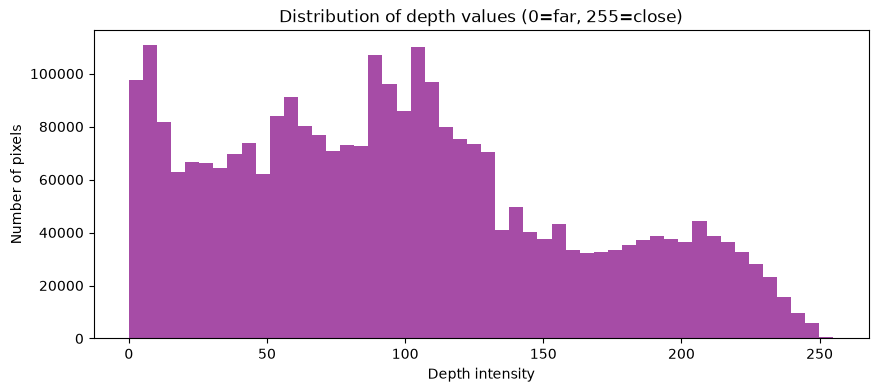

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(depth_map_array.ravel(), bins=50, color='purple', alpha=0.7)
plt.title("Distribution of depth values (0=far, 255=close)")
plt.xlabel("Depth intensity")
plt.ylabel("Number of pixels")

In [11]:
mask_depths = []

for i, mask_data in enumerate(sam_result):

    binary_mask = mask_data['segmentation'] #Boolean matrix: True if there is a mask, False elsewhere
    
    pixels_in_mask = depth_map_array[binary_mask]
    
    median_depth = np.median(pixels_in_mask)
    
    mask_depths.append({
        "id": i,
        "depth": median_depth,
        "mask": binary_mask
    })


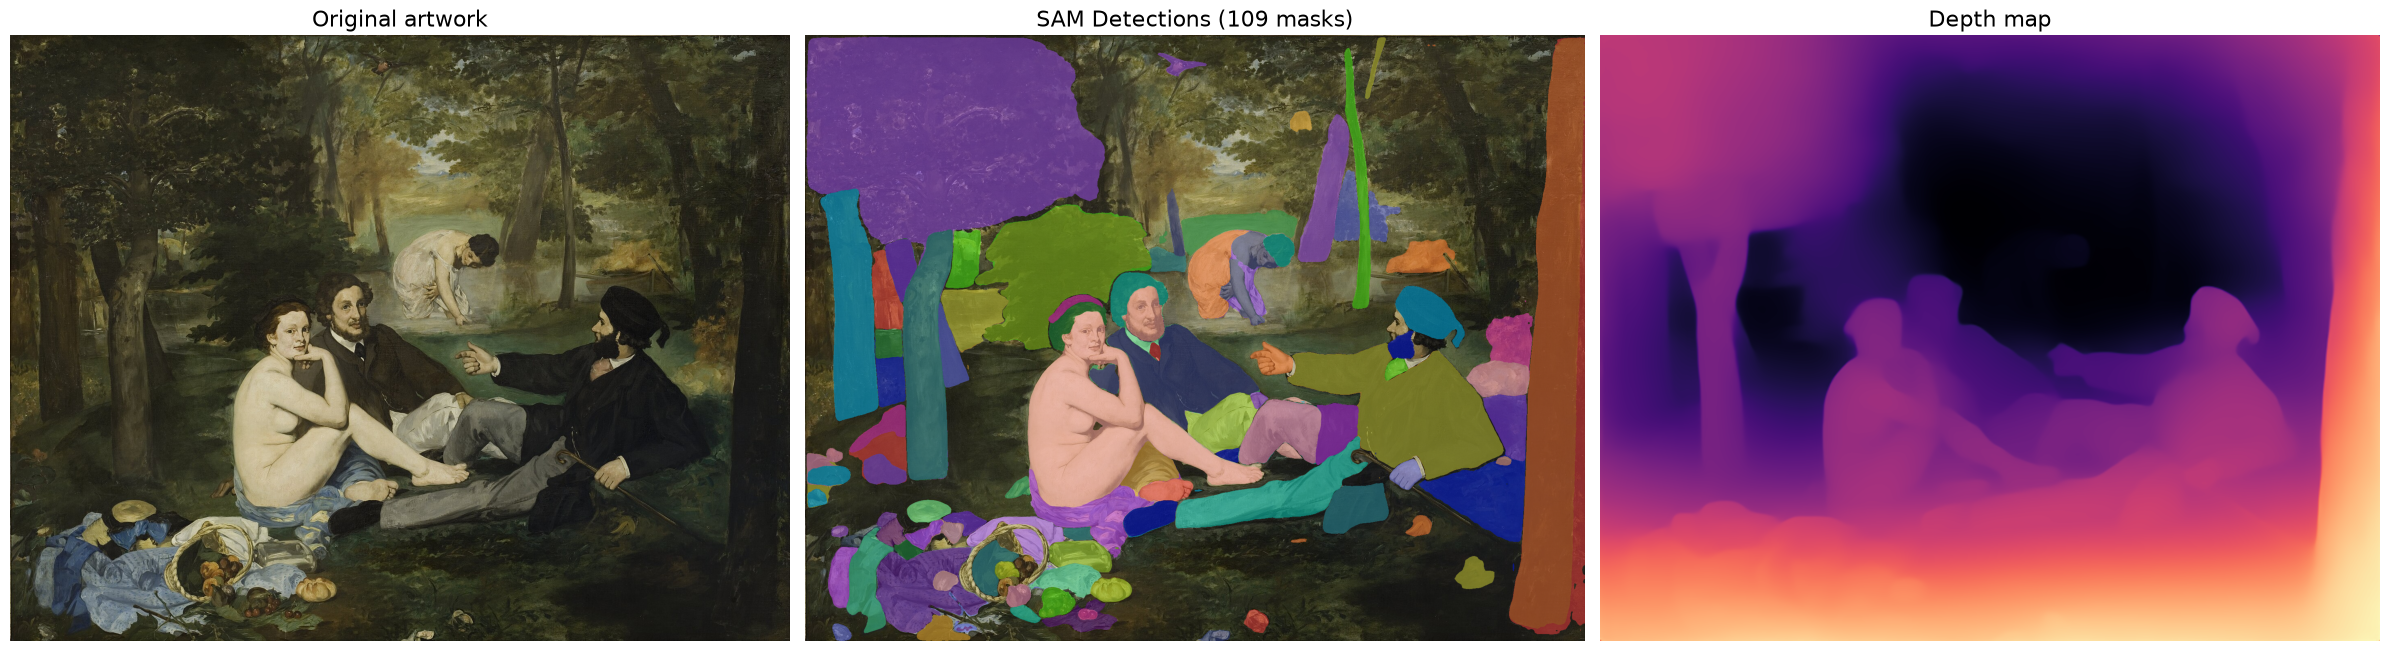

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].imshow(image_rgb)
axes[0].set_title("Original artwork", fontsize=16)
axes[0].axis("off")

axes[1].imshow(annotated_image_rgb)
axes[1].set_title(f"SAM Detections ({len(sam_result)} masks)", fontsize=16)
axes[1].axis("off")

axes[2].imshow(depth_map_array, cmap='magma')
axes[2].set_title("Depth map", fontsize=16)
axes[2].axis("off")

plt.tight_layout()


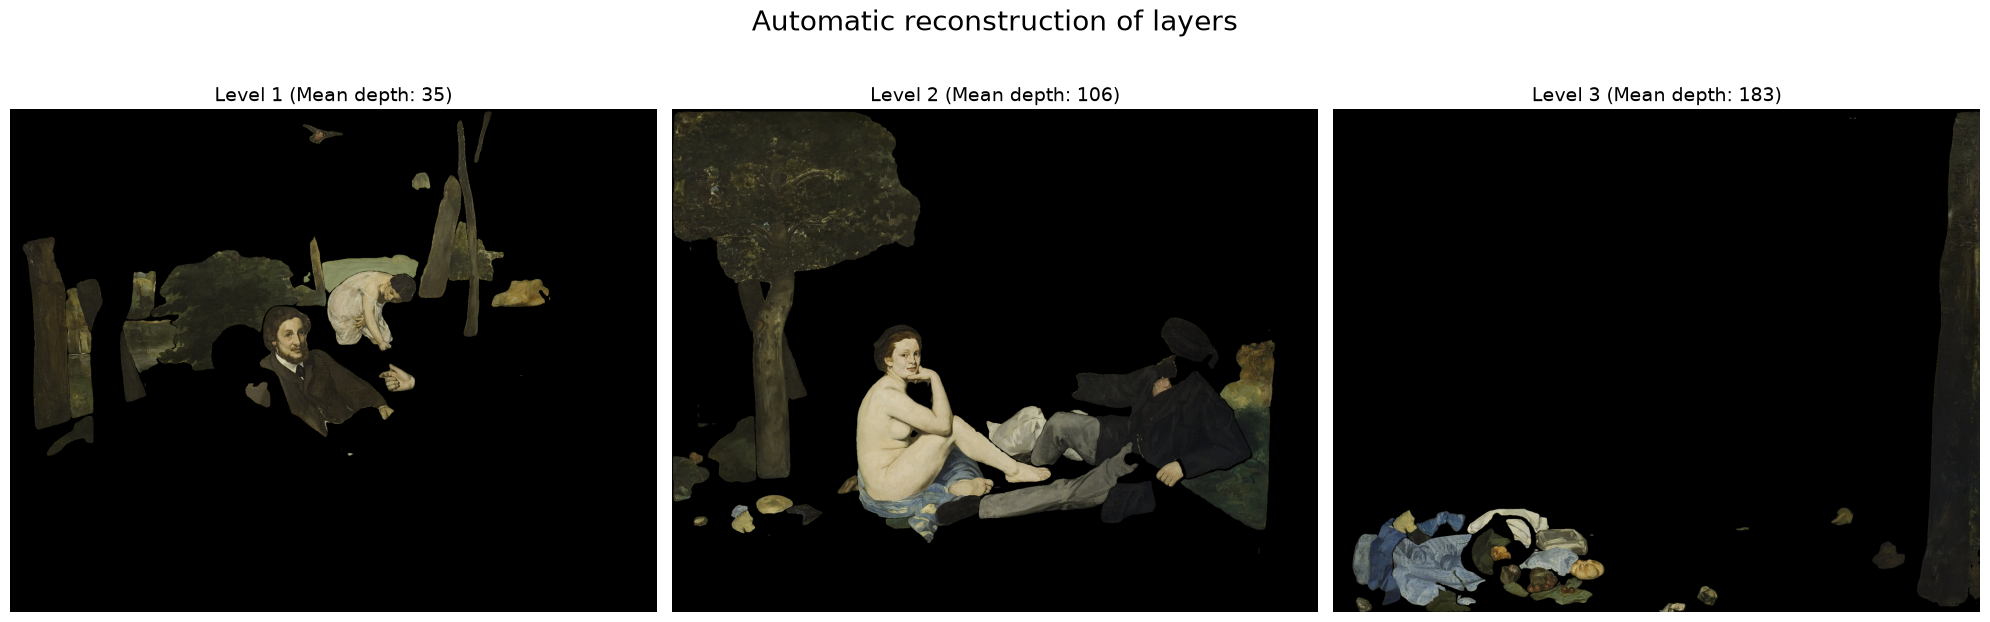

In [14]:
from sklearn.cluster import KMeans

X = np.array([item['depth'] for item in mask_depths]).reshape(-1, 1)

# Estimated K=3 by analyzing the histogram
layers_number = 3
kmeans = KMeans(n_clusters=layers_number, random_state=42)

cluster_id = kmeans.fit_predict(X)

for i, item in enumerate(mask_depths):
    item['cluster'] = cluster_id[i]


# base black image to visualize each cluster
image_layers = [np.zeros_like(image_rgb) for _ in range(layers_number)]

for item in mask_depths:
    cluster_id = item['cluster']
    boolean_mask = item['mask'] 
    
    # Copying pixels from original image only where mask =True
    image_layers[cluster_id][boolean_mask] = image_rgb[boolean_mask]

centroid = kmeans.cluster_centers_.flatten()
levels_order = np.argsort(centroid)


fig, axes = plt.subplots(1, layers_number, figsize=(20, 6))

for i, ordered_id in enumerate(levels_order):
    axes[i].imshow(image_layers[ordered_id])
    mean_depth = centroid[ordered_id]
    axes[i].set_title(f"Level {i+1} (Mean depth: {mean_depth:.0f})", fontsize=14)
    axes[i].axis('off')

plt.suptitle("Automatic reconstruction of layers", fontsize=20, y=1.05)
plt.tight_layout()
